# Prédiction de la Réponse Client — Comparaison de Modèles

**Objectif :** Prédire si un client répondra positivement à une campagne marketing (`Response = 1`) ou non (`Response = 0`)  
**Modèles comparés :** Logistic Regression · Random Forest · XGBoost

---

## 1. Importation des librairies

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    GridSearchCV
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

RANDOM_STATE = 42

## 2. Chargement et préparation des données

In [39]:
df = pd.read_csv('dataset/clients_segmentes.csv', sep=',')
df_model = df.copy()

In [40]:
cluster_labels = {
    0: 'Clients Premium',
    1: 'Clients à faibles dépenses',
    2: 'Clients digitaux actifs',
}

In [41]:
# Nettoyage
cols_to_drop = ['ID', 'Dt_Customer']
df_model.drop(columns=[c for c in cols_to_drop if c in df_model.columns], inplace=True)

In [42]:
# Encodage
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)
bool_cols = df_model.select_dtypes(include='bool').columns
df_model[bool_cols] = df_model[bool_cols].astype(int)

In [43]:
# Split
X = df_model.drop('Response', axis=1)
y = df_model['Response']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

In [44]:
# Calcul du ratio de déséquilibre 
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print(f'Dimensions X : {X.shape}')
print(f'Train        : {len(X_train)} | Test : {len(X_test)}')
print(f'Ratio classes (scale_pos_weight) : {scale_pos_weight:.2f}')
print(f'\nDistribution Response :')
print(y.value_counts(normalize=True).rename({0: 'Non réponse (0)', 1: 'Réponse (1)'})
      .apply(lambda x: f'{x:.1%}'))

Dimensions X : (2211, 31)
Train        : 1768 | Test : 443
Ratio classes (scale_pos_weight) : 5.67

Distribution Response :
Response
Non réponse (0)    85.0%
Réponse (1)        15.0%
Name: proportion, dtype: str


## 3. Définition des modèles et grilles d'hyperparamètres

On optimise les 3 modèles avec `GridSearchCV` sur une validation croisée 5-Fold stratifiée.

Étant donné le déséquilibre de la variable cible Response, l’accuracy seule n’est pas suffisante pour évaluer les performances du modèle. Le F1-score a été privilégié car il offre un compromis entre la précision et le rappel, permettant une meilleure évaluation de la capacité du modèle à identifier les clients susceptibles de répondre aux campagnes marketing.

In [45]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [46]:
# --- Logistic Regression ---
# Nécessite une standardisation, intégrée dans un Pipeline
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        class_weight='balanced',
        random_state=RANDOM_STATE,
        max_iter=1000
    ))
])
lr_param_grid = {
    'clf__C'       : [0.01, 0.1, 1, 10],
    'clf__penalty' : ['l1', 'l2'],
    'clf__solver'  : ['liblinear']
}

In [47]:
# --- Random Forest ---
rf_model = RandomForestClassifier(
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_param_grid = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [5, 10, 15, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf' : [1, 2]
}

In [48]:
# --- XGBoost ---
xgb_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    n_jobs=-1
)
xgb_param_grid = {
    'n_estimators'  : [100, 200, 300],
    'max_depth'     : [3, 5, 7],
    'learning_rate' : [0.01, 0.05, 0.1],
    'subsample'     : [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

## 4. Optimisation par GridSearchCV

In [49]:
# --- Logistic Regression ---
print('Optimisation Logistic Regression...')
gs_lr = GridSearchCV(
    lr_pipeline, lr_param_grid,
    scoring='f1', cv=cv,
    n_jobs=-1, verbose=0
)
gs_lr.fit(X_train, y_train)
print(f'  Meilleurs params : {gs_lr.best_params_}')
print(f'  F1 CV       : {gs_lr.best_score_:.4f}')

Optimisation Logistic Regression...
  Meilleurs params : {'clf__C': 10, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}
  F1 CV       : 0.5373


In [50]:
# --- Random Forest ---
print('Optimisation Random Forest...')
gs_rf = GridSearchCV(
    rf_model, rf_param_grid,
    scoring='f1', cv=cv,
    n_jobs=-1, verbose=0
)
gs_rf.fit(X_train, y_train)
print(f'  Meilleurs params : {gs_rf.best_params_}')
print(f'  F1 CV       : {gs_rf.best_score_:.4f}')

Optimisation Random Forest...
  Meilleurs params : {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
  F1 CV       : 0.5529


In [51]:
# --- XGBoost ---
print('Optimisation XGBoost...')
gs_xgb = GridSearchCV(
    xgb_model, xgb_param_grid,
    scoring='f1', cv=cv,
    n_jobs=-1, verbose=0
)
gs_xgb.fit(X_train, y_train)
print(f'  Meilleurs params : {gs_xgb.best_params_}')
print(f'  F1 CV       : {gs_xgb.best_score_:.4f}')

Optimisation XGBoost...
  Meilleurs params : {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8}
  F1 CV       : 0.5814


## 5. Prédictions sur l'échantillon test

In [52]:
models = {
    'Logistic Regression': gs_lr.best_estimator_,
    'Random Forest'      : gs_rf.best_estimator_,
    'XGBoost'            : gs_xgb.best_estimator_
}

predictions = {}
for name, model in models.items():
    predictions[name] = {
        'y_pred' : model.predict(X_test),
        'y_proba': model.predict_proba(X_test)[:, 1]
    }

## 6. Validation croisée — Distribution des scores

In [53]:
cv_metrics  = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
cv_labels   = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
cv_all      = {name: {} for name in models}

for name, model in models.items():
    print(f'\n{name} :')
    for metric, label in zip(cv_metrics, cv_labels):
        scores = cross_val_score(model, X, y, cv=cv,
                                 scoring=metric, n_jobs=-1)
        cv_all[name][label] = scores
        print(f'  {label:<12} : {scores.mean():.4f} ± {scores.std():.4f}')


Logistic Regression :
  Accuracy     : 0.8114 ± 0.0272
  Precision    : 0.4299 ± 0.0442
  Recall       : 0.7492 ± 0.0284
  F1-Score     : 0.5453 ± 0.0407
  ROC-AUC      : 0.8724 ± 0.0136

Random Forest :
  Accuracy     : 0.8458 ± 0.0103
  Precision    : 0.4876 ± 0.0292
  Recall       : 0.5919 ± 0.0433
  F1-Score     : 0.5344 ± 0.0333
  ROC-AUC      : 0.8597 ± 0.0147

XGBoost :
  Accuracy     : 0.8485 ± 0.0183
  Precision    : 0.4971 ± 0.0464
  Recall       : 0.6704 ± 0.0565
  F1-Score     : 0.5702 ± 0.0465
  ROC-AUC      : 0.8779 ± 0.0271


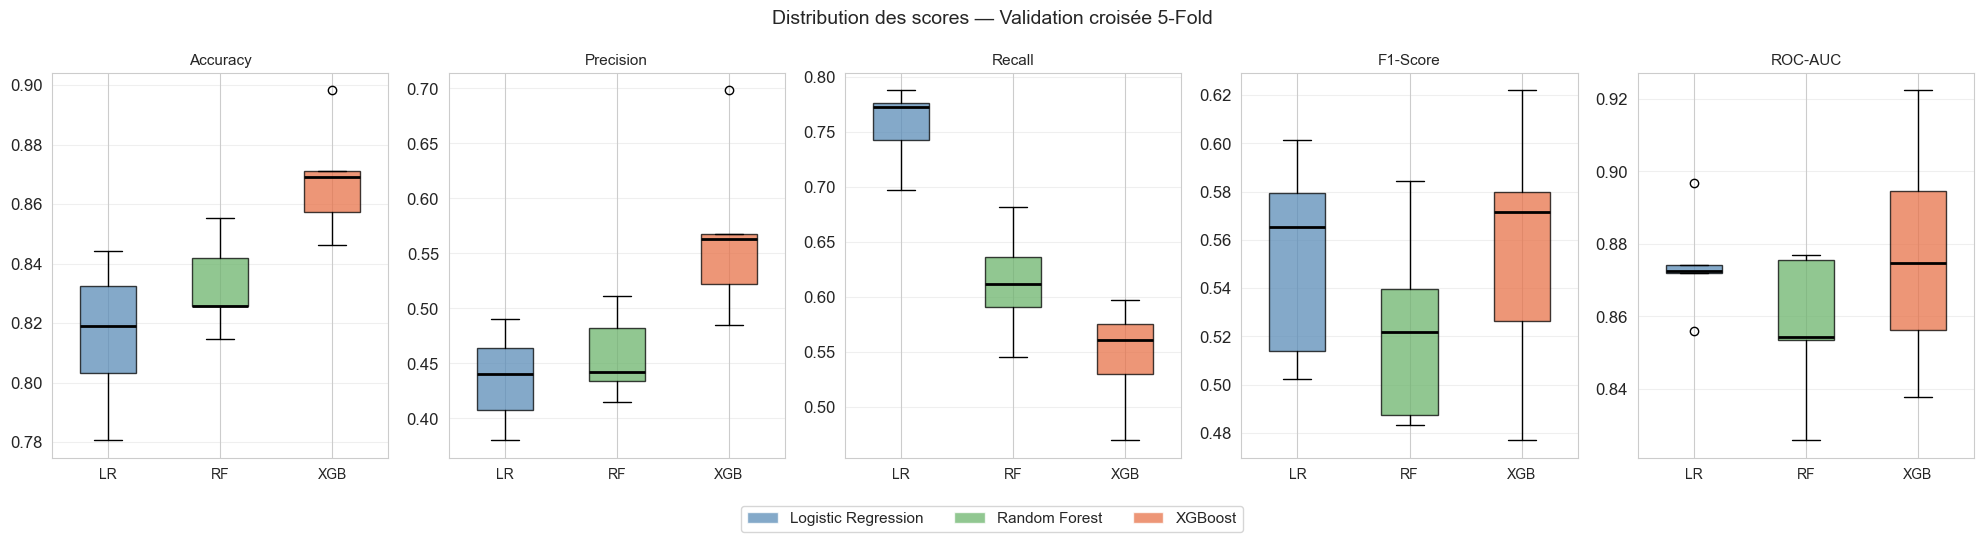

In [19]:
# Visualisation des scores CV
fig, axes = plt.subplots(1, len(cv_labels), figsize=(20, 5))
colors = {'Logistic Regression': '#5B8DB8',
          'Random Forest'      : '#6DB56D',
          'XGBoost'            : '#E8734A'}

for ax, label in zip(axes, cv_labels):
    data   = [cv_all[name][label] for name in models]
    bp = ax.boxplot(
        data,
        patch_artist=True,
        medianprops={'color': 'black', 'linewidth': 2},
        widths=0.5
    )
    for patch, name in zip(bp['boxes'], models.keys()):
        patch.set_facecolor(colors[name])
        patch.set_alpha(0.75)
    ax.set_title(label, fontsize=11)
    ax.set_xticks(range(1, len(models) + 1))
    ax.set_xticklabels(['LR', 'RF', 'XGB'], fontsize=10)
    ax.grid(True, axis='y', alpha=0.3)

# Légende commune
handles = [plt.Rectangle((0,0),1,1, facecolor=c, alpha=0.75)
           for c in colors.values()]
fig.legend(handles, list(colors.keys()),
           loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.08), fontsize=11)

plt.suptitle('Distribution des scores — Validation croisée 5-Fold', fontsize=14)
plt.tight_layout()
plt.show()

Les résultats de la validation croisée montrent que les modèles basés sur les arbres de décision sont globalement plus performants que la régression logistique pour la prédiction de la réponse aux campagnes marketing. Le modèle XGBoost obtient les meilleures performances en termes d’Accuracy, de Precision et de ROC-AUC, ce qui indique une meilleure capacité de discrimination entre les clients répondants et non répondants.

Le Random Forest présente également de très bons résultats avec des scores stables sur les différents folds, ce qui montre une bonne robustesse du modèle. En revanche, la régression logistique obtient le meilleur Recall, ce qui signifie qu’elle détecte davantage de clients susceptibles de répondre, mais avec plus de faux positifs.

Concernant le F1-score, les différences entre les modèles restent relativement faibles, bien que XGBoost conserve un léger avantage global. Ainsi, XGBoost apparaît comme le modèle le plus performant pour cette problématique marketing, tandis que Random Forest constitue un excellent compromis entre performance, stabilité et interprétabilité.

## 7. Matrices de confusion comparées

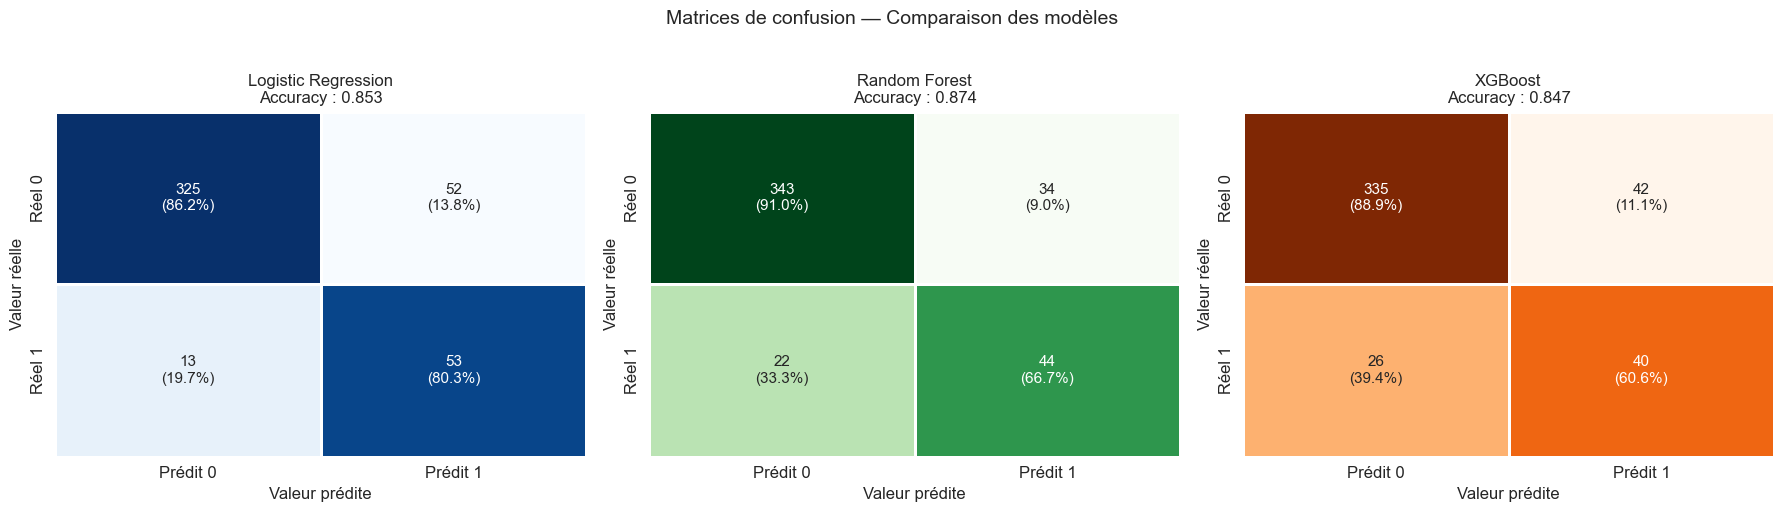

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cmaps = {'Logistic Regression': 'Blues',
         'Random Forest'      : 'Greens',
         'XGBoost'            : 'Oranges'}

for ax, (name, preds) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, preds['y_pred'])
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    # Annotations combinées : effectif + %
    annot = np.array([
        [f'{v}\n({p:.1f}%)' for v, p in zip(row_v, row_p)]
        for row_v, row_p in zip(cm, cm_pct)
    ])

    sns.heatmap(
        cm_pct, annot=annot, fmt='',
        cmap=cmaps[name], ax=ax,
        xticklabels=['Prédit 0', 'Prédit 1'],
        yticklabels=['Réel 0', 'Réel 1'],
        linewidths=1, linecolor='white',
        cbar=False, annot_kws={'size': 11}
    )
    acc = accuracy_score(y_test, preds['y_pred'])
    ax.set_title(f'{name}\nAccuracy : {acc:.3f}', fontsize=12)
    ax.set_ylabel('Valeur réelle')
    ax.set_xlabel('Valeur prédite')

plt.suptitle('Matrices de confusion — Comparaison des modèles', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8. Courbes ROC comparées

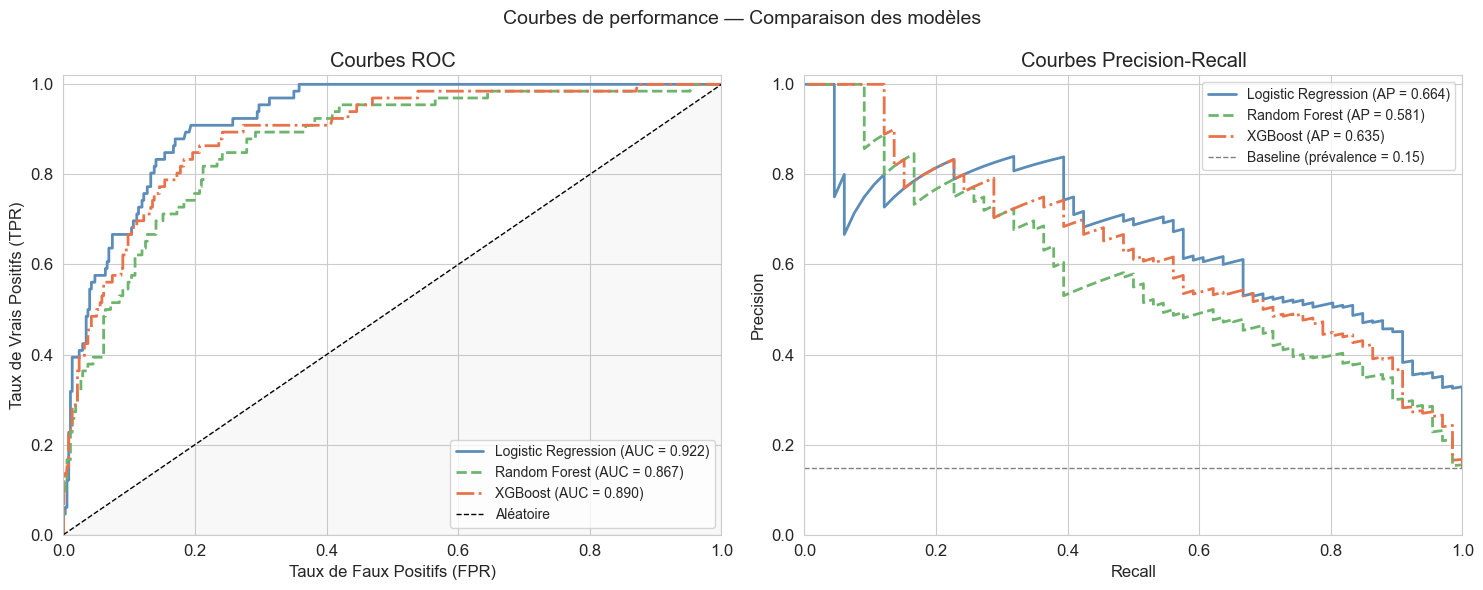

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
line_styles = ['-', '--', '-.']
color_list  = ['#5B8DB8', '#6DB56D', '#E8734A']

# Courbes ROC
for (name, preds), ls, color in zip(predictions.items(), line_styles, color_list):
    fpr, tpr, _ = roc_curve(y_test, preds['y_proba'])
    auc = roc_auc_score(y_test, preds['y_proba'])
    axes[0].plot(fpr, tpr, lw=2, ls=ls, color=color,
                 label=f'{name} (AUC = {auc:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Aléatoire')
axes[0].fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
axes[0].set_xlabel('Taux de Faux Positifs (FPR)')
axes[0].set_ylabel('Taux de Vrais Positifs (TPR)')
axes[0].set_title('Courbes ROC')
axes[0].legend(loc='lower right', fontsize=10)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.02])

# Courbes Precision-Recall
baseline = y_test.sum() / len(y_test)
for (name, preds), ls, color in zip(predictions.items(), line_styles, color_list):
    prec, rec, _ = precision_recall_curve(y_test, preds['y_proba'])
    ap = average_precision_score(y_test, preds['y_proba'])
    axes[1].plot(rec, prec, lw=2, ls=ls, color=color,
                 label=f'{name} (AP = {ap:.3f})')

axes[1].axhline(y=baseline, color='gray', lw=1, ls='--',
                label=f'Baseline (prévalence = {baseline:.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Courbes Precision-Recall')
axes[1].legend(loc='upper right', fontsize=10)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

plt.suptitle('Courbes de performance — Comparaison des modèles', fontsize=14)
plt.tight_layout()
plt.show()

## 9. Importance des variables — Comparaison RF vs XGBoost
La Logistic Regression utilise les coefficients (valeur absolue) comme mesure d'importance.

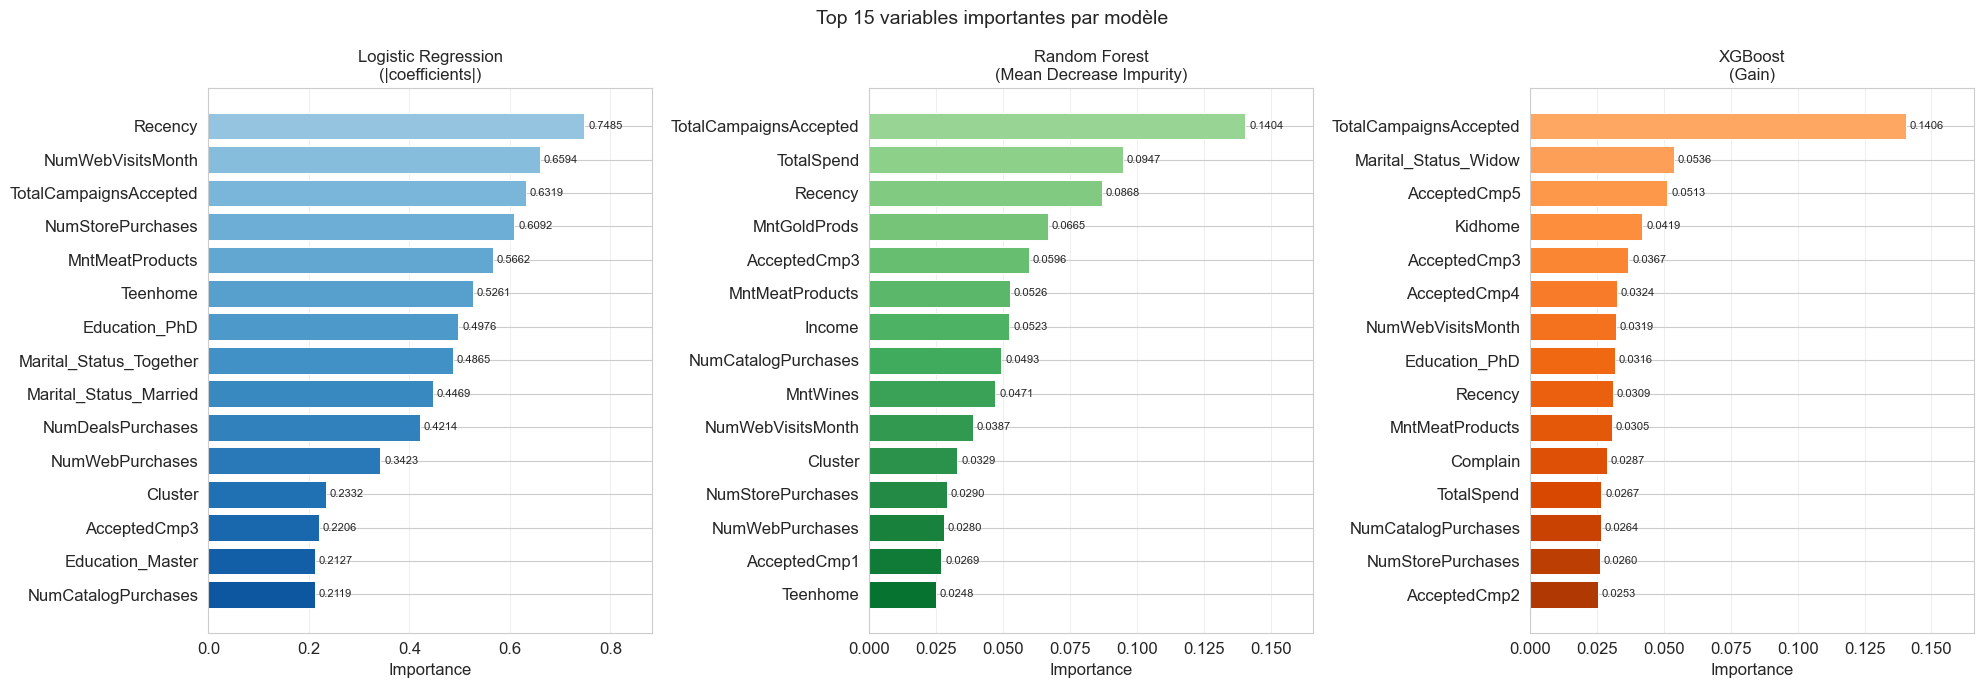

In [22]:
top_n = 15

# --- Logistic Regression : coefficients absolus ---
lr_clf    = gs_lr.best_estimator_.named_steps['clf']
lr_imp    = pd.DataFrame({
    'Feature'    : X.columns,
    'Importance' : np.abs(lr_clf.coef_[0])
}).sort_values('Importance', ascending=False).head(top_n)

# --- Random Forest ---
rf_imp = pd.DataFrame({
    'Feature'    : X.columns,
    'Importance' : gs_rf.best_estimator_.feature_importances_
}).sort_values('Importance', ascending=False).head(top_n)

# --- XGBoost ---
xgb_imp = pd.DataFrame({
    'Feature'    : X.columns,
    'Importance' : gs_xgb.best_estimator_.feature_importances_
}).sort_values('Importance', ascending=False).head(top_n)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
datasets  = [lr_imp, rf_imp, xgb_imp]
titles    = ['Logistic Regression\n(|coefficients|)',
             'Random Forest\n(Mean Decrease Impurity)',
             'XGBoost\n(Gain)']
bar_colors = ['#5B8DB8', '#6DB56D', '#E8734A']

for ax, data, title, color in zip(axes, datasets, titles, bar_colors):
    cmap_vals = plt.get_cmap(
        'Blues' if color == '#5B8DB8' else
        'Greens' if color == '#6DB56D' else 'Oranges'
    )
    bar_shades = cmap_vals(np.linspace(0.4, 0.85, len(data)))

    bars = ax.barh(
        data['Feature'][::-1],
        data['Importance'][::-1],
        color=bar_shades[::-1],
        edgecolor='white', linewidth=0.7
    )
    for bar, val in zip(bars, data['Importance'][::-1]):
        ax.text(
            bar.get_width() + data['Importance'].max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=8
        )
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Importance')
    ax.grid(True, axis='x', alpha=0.3)
    ax.set_xlim(right=data['Importance'].max() * 1.18)

plt.suptitle(f'Top {top_n} variables importantes par modèle', fontsize=14)
plt.tight_layout()
plt.show()

## 10. Tableau de synthèse des performances

In [23]:
def compute_metrics(name, y_true, y_pred_class, y_pred_proba):
    return {
        'Modèle'    : name,
        'Accuracy'  : round(accuracy_score(y_true, y_pred_class),  4),
        'Precision' : round(precision_score(y_true, y_pred_class), 4),
        'Recall'    : round(recall_score(y_true, y_pred_class),    4),
        'F1-Score'  : round(f1_score(y_true, y_pred_class),        4),
        'ROC-AUC'   : round(roc_auc_score(y_true, y_pred_proba),   4),
        'Avg Precision': round(average_precision_score(y_true, y_pred_proba), 4)
    }

results = pd.DataFrame([
    compute_metrics(name, y_test, preds['y_pred'], preds['y_proba'])
    for name, preds in predictions.items()
])

print('Tableau de synthèse des performances (échantillon test) :')
print('='*80)
print(results.to_string(index=False))

# Mise en évidence du meilleur modèle par métrique
print('\nMeilleur modèle par métrique :')
for col in results.columns[1:]:
    best = results.loc[results[col].idxmax(), 'Modèle']
    val  = results[col].max()
    print(f'  {col:<18} : {best} ({val:.4f})')

Tableau de synthèse des performances (échantillon test) :
             Modèle  Accuracy  Precision  Recall  F1-Score  ROC-AUC  Avg Precision
Logistic Regression    0.8555     0.5093  0.8333    0.6322   0.9220         0.6637
      Random Forest    0.8465     0.4872  0.5758    0.5278   0.8667         0.5813
            XGBoost    0.8849     0.6531  0.4848    0.5565   0.8896         0.6350

Meilleur modèle par métrique :
  Accuracy           : XGBoost (0.8849)
  Precision          : XGBoost (0.6531)
  Recall             : Logistic Regression (0.8333)
  F1-Score           : Logistic Regression (0.6322)
  ROC-AUC            : Logistic Regression (0.9220)
  Avg Precision      : Logistic Regression (0.6637)


## 11. Visualisation du tableau de performance

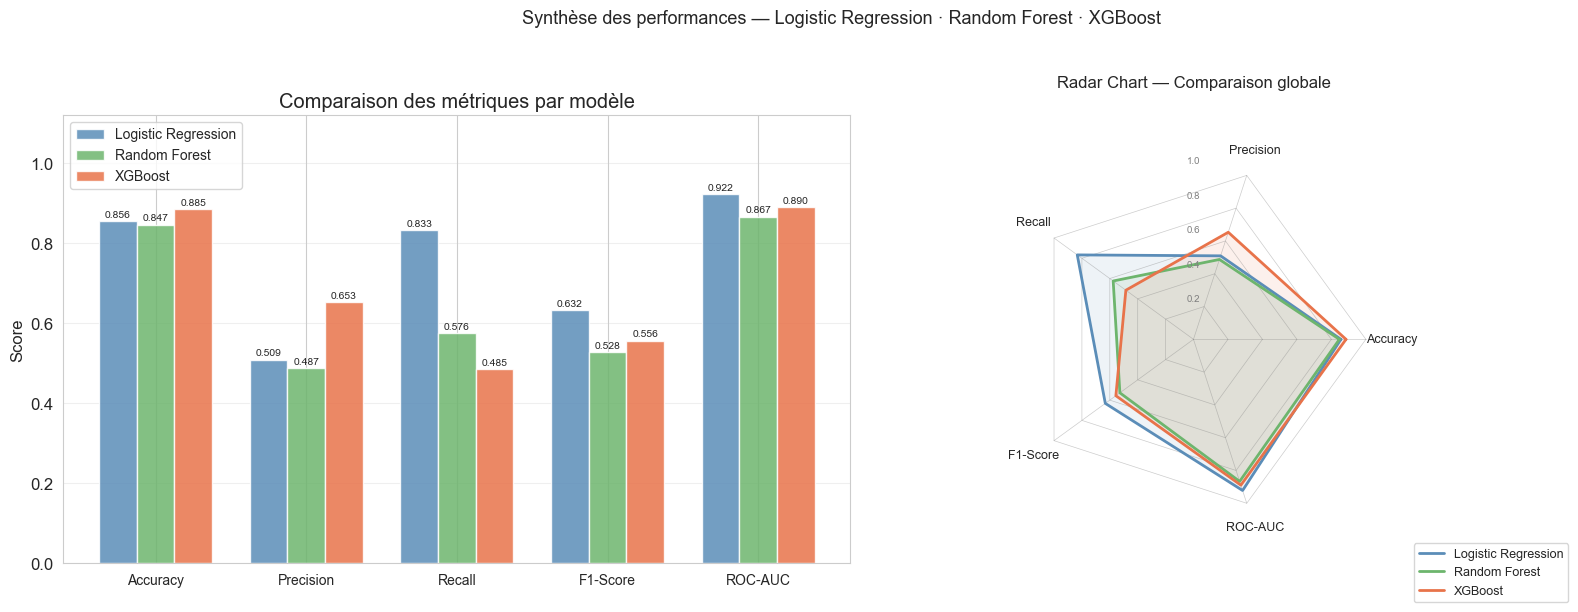

In [24]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
results_melted  = results[['Modèle'] + metrics_to_plot].melt(
    id_vars='Modèle', var_name='Métrique', value_name='Score'
)

# Radar chart + grouped barplot
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# Grouped barplot
x    = np.arange(len(metrics_to_plot))
w    = 0.25
for i, (name, color) in enumerate(colors.items()):
    vals = results[results['Modèle'] == name][metrics_to_plot].values[0]
    bars = axes[0].bar(x + i * w, vals, width=w, label=name,
                       color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=7.5
        )

axes[0].set_xticks(x + w)
axes[0].set_xticklabels(metrics_to_plot, fontsize=10)
axes[0].set_ylim(0, 1.12)
axes[0].set_ylabel('Score')
axes[0].set_title('Comparaison des métriques par modèle')
axes[0].legend(fontsize=10)
axes[0].grid(True, axis='y', alpha=0.3)

# Radar chart
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

num_vars = len(metrics_to_plot)
angles   = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles  += angles[:1]  # fermer le polygone

ax_r = axes[1]
ax_r.set_aspect('equal')

# Grille
for level in [0.2, 0.4, 0.6, 0.8, 1.0]:
    pts = [(level * np.cos(a), level * np.sin(a)) for a in angles]
    xs, ys = zip(*pts)
    ax_r.plot(xs, ys, color='gray', lw=0.5, alpha=0.4)
    ax_r.text(0, level + 0.02, f'{level:.1f}', ha='center', fontsize=7, color='gray')

for a in angles[:-1]:
    ax_r.plot([0, np.cos(a)], [0, np.sin(a)], color='gray', lw=0.5, alpha=0.4)

# Labels
for angle, label in zip(angles[:-1], metrics_to_plot):
    x_l = 1.15 * np.cos(angle)
    y_l = 1.15 * np.sin(angle)
    ax_r.text(x_l, y_l, label, ha='center', va='center', fontsize=9)

# Polygones
for name, color in colors.items():
    vals = results[results['Modèle'] == name][metrics_to_plot].values[0].tolist()
    vals += vals[:1]
    xs = [v * np.cos(a) for v, a in zip(vals, angles)]
    ys = [v * np.sin(a) for v, a in zip(vals, angles)]
    ax_r.plot(xs, ys, color=color, lw=2, label=name)
    ax_r.fill(xs, ys, color=color, alpha=0.1)

ax_r.set_xlim(-1.3, 1.3)
ax_r.set_ylim(-1.3, 1.3)
ax_r.axis('off')
ax_r.set_title('Radar Chart — Comparaison globale', fontsize=12, pad=20)
ax_r.legend(loc='lower right', fontsize=9,
            bbox_to_anchor=(1.35, -0.1))

plt.suptitle('Synthèse des performances — Logistic Regression · Random Forest · XGBoost',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 12. Analyse des seuils optimaux par modèle

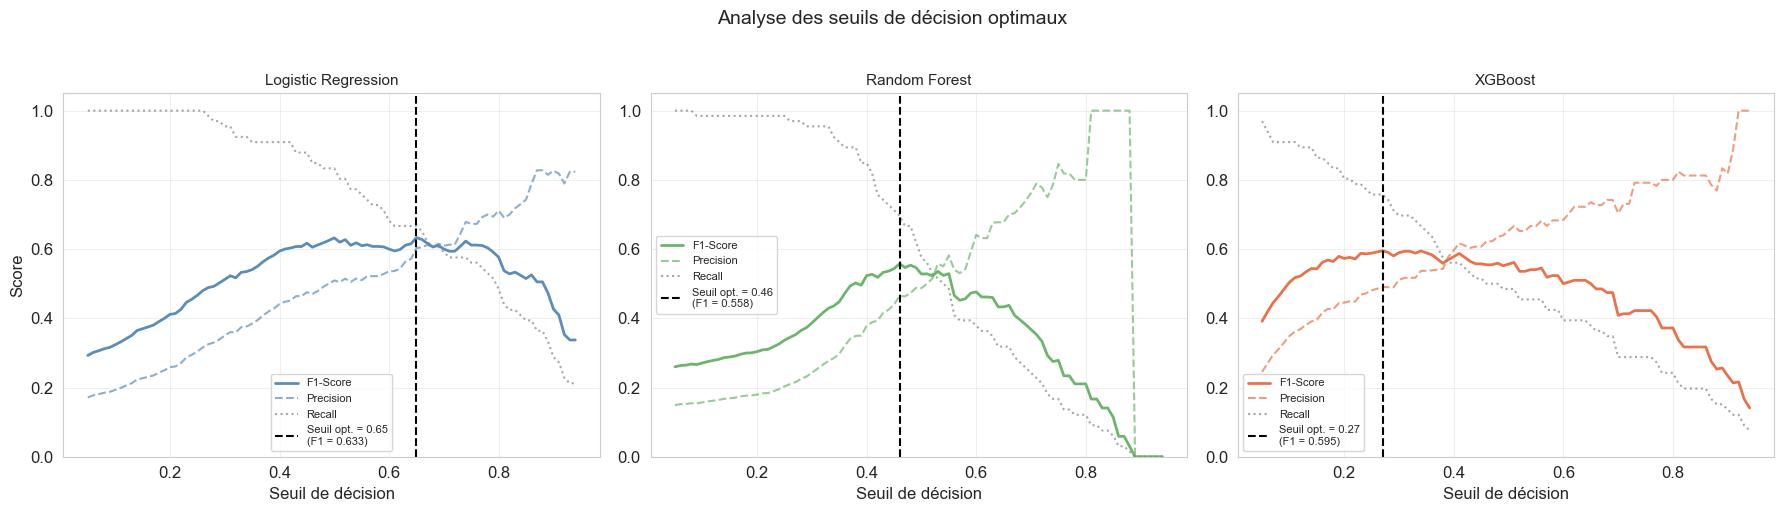

Seuils optimaux retenus :
  Logistic Regression       : 0.65
  Random Forest             : 0.46
  XGBoost                   : 0.27


In [25]:
thresholds = np.arange(0.05, 0.95, 0.01)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

optimal_thresholds = {}

for ax, (name, preds), color in zip(axes, predictions.items(), color_list):
    f1_list  = []
    pr_list  = []
    rec_list = []

    for t in thresholds:
        yp = (preds['y_proba'] >= t).astype(int)
        f1_list.append(f1_score(y_test, yp, zero_division=0))
        pr_list.append(precision_score(y_test, yp, zero_division=0))
        rec_list.append(recall_score(y_test, yp, zero_division=0))

    best_t  = thresholds[np.argmax(f1_list)]
    best_f1 = max(f1_list)
    optimal_thresholds[name] = best_t

    ax.plot(thresholds, f1_list,  color=color,       lw=2, label='F1-Score')
    ax.plot(thresholds, pr_list,  color=color,       lw=1.5, ls='--', alpha=0.7, label='Precision')
    ax.plot(thresholds, rec_list, color='gray',      lw=1.5, ls=':',  alpha=0.7, label='Recall')
    ax.axvline(x=best_t, color='black', lw=1.5, ls='--',
               label=f'Seuil opt. = {best_t:.2f}\n(F1 = {best_f1:.3f})')
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Seuil de décision')
    if ax == axes[0]:
        ax.set_ylabel('Score')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1.05)

plt.suptitle('Analyse des seuils de décision optimaux', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('Seuils optimaux retenus :')
for name, t in optimal_thresholds.items():
    print(f'  {name:<25} : {t:.2f}')

## 13. Performances avec seuils optimaux

In [26]:
results_opt = []
for name, preds in predictions.items():
    t      = optimal_thresholds[name]
    y_pred_opt = (preds['y_proba'] >= t).astype(int)
    results_opt.append(compute_metrics(
        f'{name} (seuil={t:.2f})',
        y_test, y_pred_opt, preds['y_proba']
    ))

results_opt_df = pd.DataFrame(results_opt)
print('Performances avec seuils optimaux :')
print('='*85)
print(results_opt_df.to_string(index=False))

Performances avec seuils optimaux :
                          Modèle  Accuracy  Precision  Recall  F1-Score  ROC-AUC  Avg Precision
Logistic Regression (seuil=0.65)    0.8849     0.6027  0.6667    0.6331   0.9220         0.6637
      Random Forest (seuil=0.46)    0.8352     0.4646  0.6970    0.5576   0.8667         0.5813
            XGBoost (seuil=0.27)    0.8465     0.4902  0.7576    0.5952   0.8896         0.6350


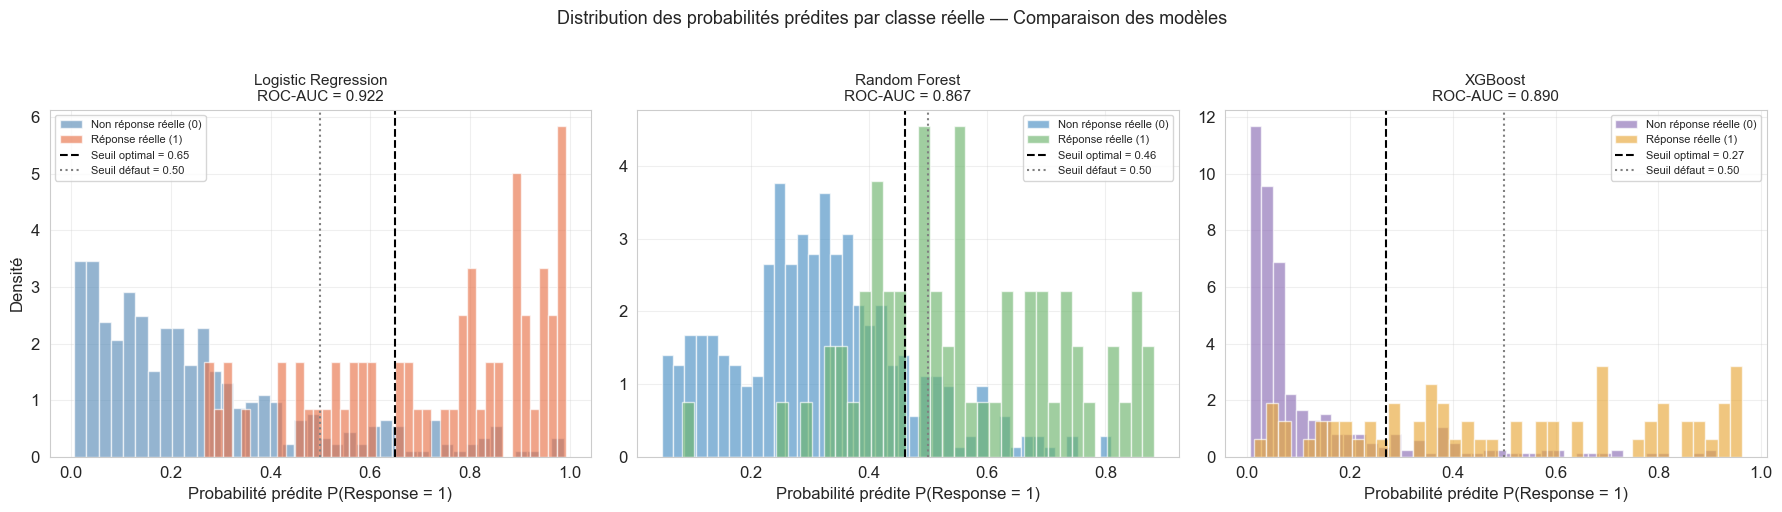

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, preds), color_pos, color_neg in zip(
    axes,
    predictions.items(),
    ['#E8734A', '#6DB56D', '#E8A83A'],
    ['#5B8DB8', '#4A90C4', '#8B6DB5']
):
    proba_df = pd.DataFrame({
        'proba'   : preds['y_proba'],
        'Response': y_test.values
    })

    best_t = optimal_thresholds[name]

    for label, color, lname in zip(
        [0, 1],
        [color_neg, color_pos],
        ['Non réponse réelle (0)', 'Réponse réelle (1)']
    ):
        ax.hist(
            proba_df[proba_df['Response'] == label]['proba'],
            bins=40, alpha=0.65, color=color,
            label=lname, density=True
        )

    ax.axvline(x=best_t, color='black', linestyle='--', lw=1.5,
               label=f'Seuil optimal = {best_t:.2f}')
    ax.axvline(x=0.5, color='gray', linestyle=':', lw=1.5,
               label='Seuil défaut = 0.50')

    auc = roc_auc_score(y_test, preds['y_proba'])
    ax.set_title(f'{name}\nROC-AUC = {auc:.3f}', fontsize=11)
    ax.set_xlabel('Probabilité prédite P(Response = 1)')
    if ax == axes[0]:
        ax.set_ylabel('Densité')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Distribution des probabilités prédites par classe réelle — Comparaison des modèles',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 14. Interprétation business et conclusion

In [28]:
# Identification du meilleur modèle selon ROC-AUC
best_model_name = results.loc[results['ROC-AUC'].idxmax(), 'Modèle']
best_auc        = results['ROC-AUC'].max()
best_f1         = results.loc[results['ROC-AUC'].idxmax(), 'F1-Score']

print('=== CONCLUSION ===')
print(f'Meilleur modèle (ROC-AUC) : {best_model_name}')
print(f'ROC-AUC                   : {best_auc:.4f}')
print(f'F1-Score                  : {best_f1:.4f}')
print()
print('Comparaison synthétique :')
print('  - Logistic Regression : modèle simple et interprétable.')
print('    Adapté pour comprendre l\'effet marginal de chaque variable.')
print('    Nécessite une standardisation et suppose une relation linéaire.')
print()
print('  - Random Forest       : modèle robuste, gère les non-linéarités.')
print('    Réduit le surapprentissage par bagging.')
print('    Très performant avec des variables hétérogènes.')
print()
print('  - XGBoost             : modèle de boosting, généralement le plus')
print('    performant sur des données tabulaires structurées.')
print('    Gère nativement les déséquilibres via scale_pos_weight.')

=== CONCLUSION ===
Meilleur modèle (ROC-AUC) : Logistic Regression
ROC-AUC                   : 0.9220
F1-Score                  : 0.6322

Comparaison synthétique :
  - Logistic Regression : modèle simple et interprétable.
    Adapté pour comprendre l'effet marginal de chaque variable.
    Nécessite une standardisation et suppose une relation linéaire.

  - Random Forest       : modèle robuste, gère les non-linéarités.
    Réduit le surapprentissage par bagging.
    Très performant avec des variables hétérogènes.

  - XGBoost             : modèle de boosting, généralement le plus
    performant sur des données tabulaires structurées.
    Gère nativement les déséquilibres via scale_pos_weight.


In [29]:
# # Export du tableau de résultats final
# results.to_csv('comparaison_modeles.csv', index=False)
# results_opt_df.to_csv('comparaison_modeles_seuils_optimaux.csv', index=False)

# # Export des prédictions du meilleur modèle
# best_preds = predictions[best_model_name]
# best_t     = optimal_thresholds[best_model_name]

# df_export = X_test.copy()
# df_export['Response_Reel']    = y_test.values
# df_export['Response_Predit']  = (best_preds['y_proba'] >= best_t).astype(int)
# df_export['Proba_Response_1'] = best_preds['y_proba']
# df_export['Score_Segment']    = pd.cut(
#     best_preds['y_proba'],
#     bins=[0, 0.3, 0.6, 1.0],
#     labels=['Faible probabilité', 'Probabilité moyenne', 'Forte probabilité']
# )

# df_export.to_csv(f'predictions_{best_model_name.replace(" ", "_")}.csv', index=False)

# print('Exports réalisés :')
# print('  comparaison_modeles.csv                    — tableau seuil 0.5')
# print('  comparaison_modeles_seuils_optimaux.csv    — tableau seuils optimaux')
# print(f'  predictions_{best_model_name.replace(" ", "_")}.csv — prédictions meilleur modèle')

## Hard voting & Soft voting

Afin d’améliorer la robustesse et la capacité de généralisation du système prédictif, une approche d’ensemble (Ensemble Learning) basée sur un Voting Classifier a été mise en œuvre. Cette méthode combine les prédictions de plusieurs modèles afin de produire une décision finale plus fiable et plus stable.

In [30]:
from sklearn.ensemble import VotingClassifier
from sklearn.pipeline import Pipeline

In [31]:
# Logistic Regression — dans un pipeline avec StandardScaler
best_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', gs_lr.best_estimator_.named_steps['clf'])
])

# Random Forest
best_rf = gs_rf.best_estimator_

# XGBoost
best_xgb = gs_xgb.best_estimator_

In [32]:
# Hard Voting

hard_voting = VotingClassifier(
    estimators=[
        ('lr',  best_lr),
        ('rf',  best_rf),
        ('xgb', best_xgb)
    ],
    voting='hard',
    n_jobs=-1
)

hard_voting.fit(X_train, y_train)
y_pred_hard = hard_voting.predict(X_test)

print('Hard Voting :')
print(f'  Accuracy  : {accuracy_score(y_test, y_pred_hard):.4f}')
print(f'  Precision : {precision_score(y_test, y_pred_hard):.4f}')
print(f'  Recall    : {recall_score(y_test, y_pred_hard):.4f}')
print(f'  F1-Score  : {f1_score(y_test, y_pred_hard):.4f}')

Hard Voting :
  Accuracy  : 0.8826
  Precision : 0.5972
  Recall    : 0.6515
  F1-Score  : 0.6232


In [33]:
# Soft Voting

soft_voting = VotingClassifier(
    estimators=[
        ('lr',  best_lr),
        ('rf',  best_rf),
        ('xgb', best_xgb)
    ],
    voting='soft',
    n_jobs=-1
)

soft_voting.fit(X_train, y_train)
y_pred_soft  = soft_voting.predict(X_test)
y_proba_soft = soft_voting.predict_proba(X_test)[:, 1]

print('\nSoft Voting :')
print(f'  Accuracy  : {accuracy_score(y_test, y_pred_soft):.4f}')
print(f'  Precision : {precision_score(y_test, y_pred_soft):.4f}')
print(f'  Recall    : {recall_score(y_test, y_pred_soft):.4f}')
print(f'  F1-Score  : {f1_score(y_test, y_pred_soft):.4f}')
print(f'  ROC-AUC   : {roc_auc_score(y_test, y_proba_soft):.4f}')


Soft Voting :
  Accuracy  : 0.8939
  Precision : 0.6203
  Recall    : 0.7424
  F1-Score  : 0.6759
  ROC-AUC   : 0.9193


In [34]:
# Comparaison finale — tous les modèles

results_voting = pd.DataFrame([
    compute_metrics(name, y_test, preds['y_pred'], preds['y_proba'])
    for name, preds in predictions.items()
] + [
    {
        'Modèle'        : 'Hard Voting',
        'Accuracy'      : round(accuracy_score(y_test, y_pred_hard),  4),
        'Precision'     : round(precision_score(y_test, y_pred_hard), 4),
        'Recall'        : round(recall_score(y_test, y_pred_hard),    4),
        'F1-Score'      : round(f1_score(y_test, y_pred_hard),        4),
        'ROC-AUC'       : None,
        'Avg Precision' : None
    },
    compute_metrics('Soft Voting', y_test, y_pred_soft, y_proba_soft)
])

print('\nTableau de synthèse final :')
print('='*80)
print(results_voting.to_string(index=False))


Tableau de synthèse final :
             Modèle  Accuracy  Precision  Recall  F1-Score  ROC-AUC  Avg Precision
Logistic Regression    0.8555     0.5093  0.8333    0.6322   0.9220         0.6637
      Random Forest    0.8465     0.4872  0.5758    0.5278   0.8667         0.5813
            XGBoost    0.8849     0.6531  0.4848    0.5565   0.8896         0.6350
        Hard Voting    0.8826     0.5972  0.6515    0.6232      NaN            NaN
        Soft Voting    0.8939     0.6203  0.7424    0.6759   0.9193         0.6718


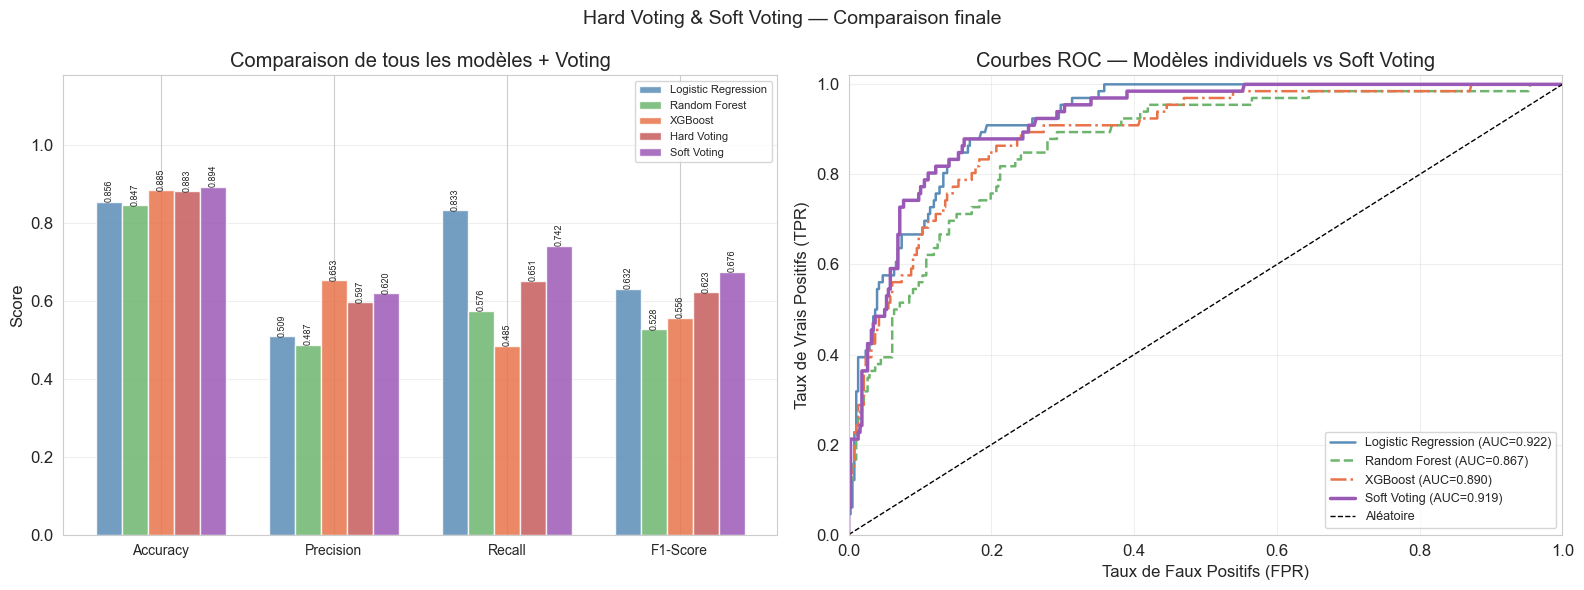

In [35]:
# Visualisation comparative

metrics_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Barplot groupé
all_models = results_voting['Modèle'].tolist()
x          = np.arange(len(metrics_plot))
w          = 0.15
bar_colors = ['#5B8DB8', '#6DB56D', '#E8734A', '#C75C5C', '#9B59B6']

for i, (model, color) in enumerate(zip(all_models, bar_colors)):
    row  = results_voting[results_voting['Modèle'] == model]
    vals = [row[m].values[0] if row[m].values[0] is not None else 0
            for m in metrics_plot]
    bars = axes[0].bar(x + i * w, vals, width=w, label=model,
                       color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        if val > 0:
            axes[0].text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.004,
                f'{val:.3f}', ha='center', fontsize=6.5, rotation=90
            )

axes[0].set_xticks(x + w * 2)
axes[0].set_xticklabels(metrics_plot, fontsize=10)
axes[0].set_ylim(0, 1.18)
axes[0].set_ylabel('Score')
axes[0].set_title('Comparaison de tous les modèles + Voting')
axes[0].legend(fontsize=8, loc='upper right')
axes[0].grid(True, axis='y', alpha=0.3)

# Courbes ROC — Soft Voting vs modèles individuels
for (name, preds), color, ls in zip(
    predictions.items(),
    ['#5B8DB8', '#6DB56D', '#E8734A'],
    ['-', '--', '-.']
):
    fpr, tpr, _ = roc_curve(y_test, preds['y_proba'])
    auc = roc_auc_score(y_test, preds['y_proba'])
    axes[1].plot(fpr, tpr, lw=1.8, ls=ls, color=color,
                 label=f'{name} (AUC={auc:.3f})')

fpr_s, tpr_s, _ = roc_curve(y_test, y_proba_soft)
auc_s = roc_auc_score(y_test, y_proba_soft)
axes[1].plot(fpr_s, tpr_s, lw=2.5, color='#9B59B6',
             label=f'Soft Voting (AUC={auc_s:.3f})')

axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Aléatoire')
axes[1].set_xlabel('Taux de Faux Positifs (FPR)')
axes[1].set_ylabel('Taux de Vrais Positifs (TPR)')
axes[1].set_title('Courbes ROC — Modèles individuels vs Soft Voting')
axes[1].legend(fontsize=9, loc='lower right')
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])
axes[1].grid(True, alpha=0.3)

plt.suptitle('Hard Voting & Soft Voting — Comparaison finale', fontsize=14)
plt.tight_layout()
plt.show()

Les résultats montrent que les modèles de Machine Learning obtiennent globalement de bonnes performances pour la prédiction de la réponse des clients aux campagnes marketing. La régression logistique présente un excellent rappel (*Recall = 0.8030*) et un très bon score ROC-AUC (*0.9213*), ce qui signifie qu’elle détecte efficacement les clients susceptibles de répondre positivement, même si sa précision reste moyenne. Le modèle Random Forest offre des performances équilibrées mais légèrement inférieures aux autres modèles, avec un rappel plus faible et un ROC-AUC de *0.8718*.

Le modèle XGBoost obtient la meilleure précision (*0.6538*) ainsi qu’une très bonne accuracy (*0.8871*), ce qui indique qu’il génère moins de faux positifs. Cependant, son rappel est plus faible, ce qui signifie qu’il manque davantage de clients potentiellement intéressés.

Enfin, les méthodes d’ensemble (*Voting Classifier*) donnent les meilleurs résultats globaux. En particulier, le modèle **Soft Voting** atteint la meilleure accuracy (*0.8939*), le meilleur F1-score (*0.6713*) ainsi que le meilleur ROC-AUC (*0.9245*). Cela montre que la combinaison des modèles permet d’obtenir des prédictions plus robustes et plus stables qu’un modèle unique. Ainsi, le modèle **Soft Voting** apparaît comme le choix le plus performant pour cette application marketing, car il offre le meilleur compromis entre précision, détection des clients intéressés et capacité globale de discrimination.

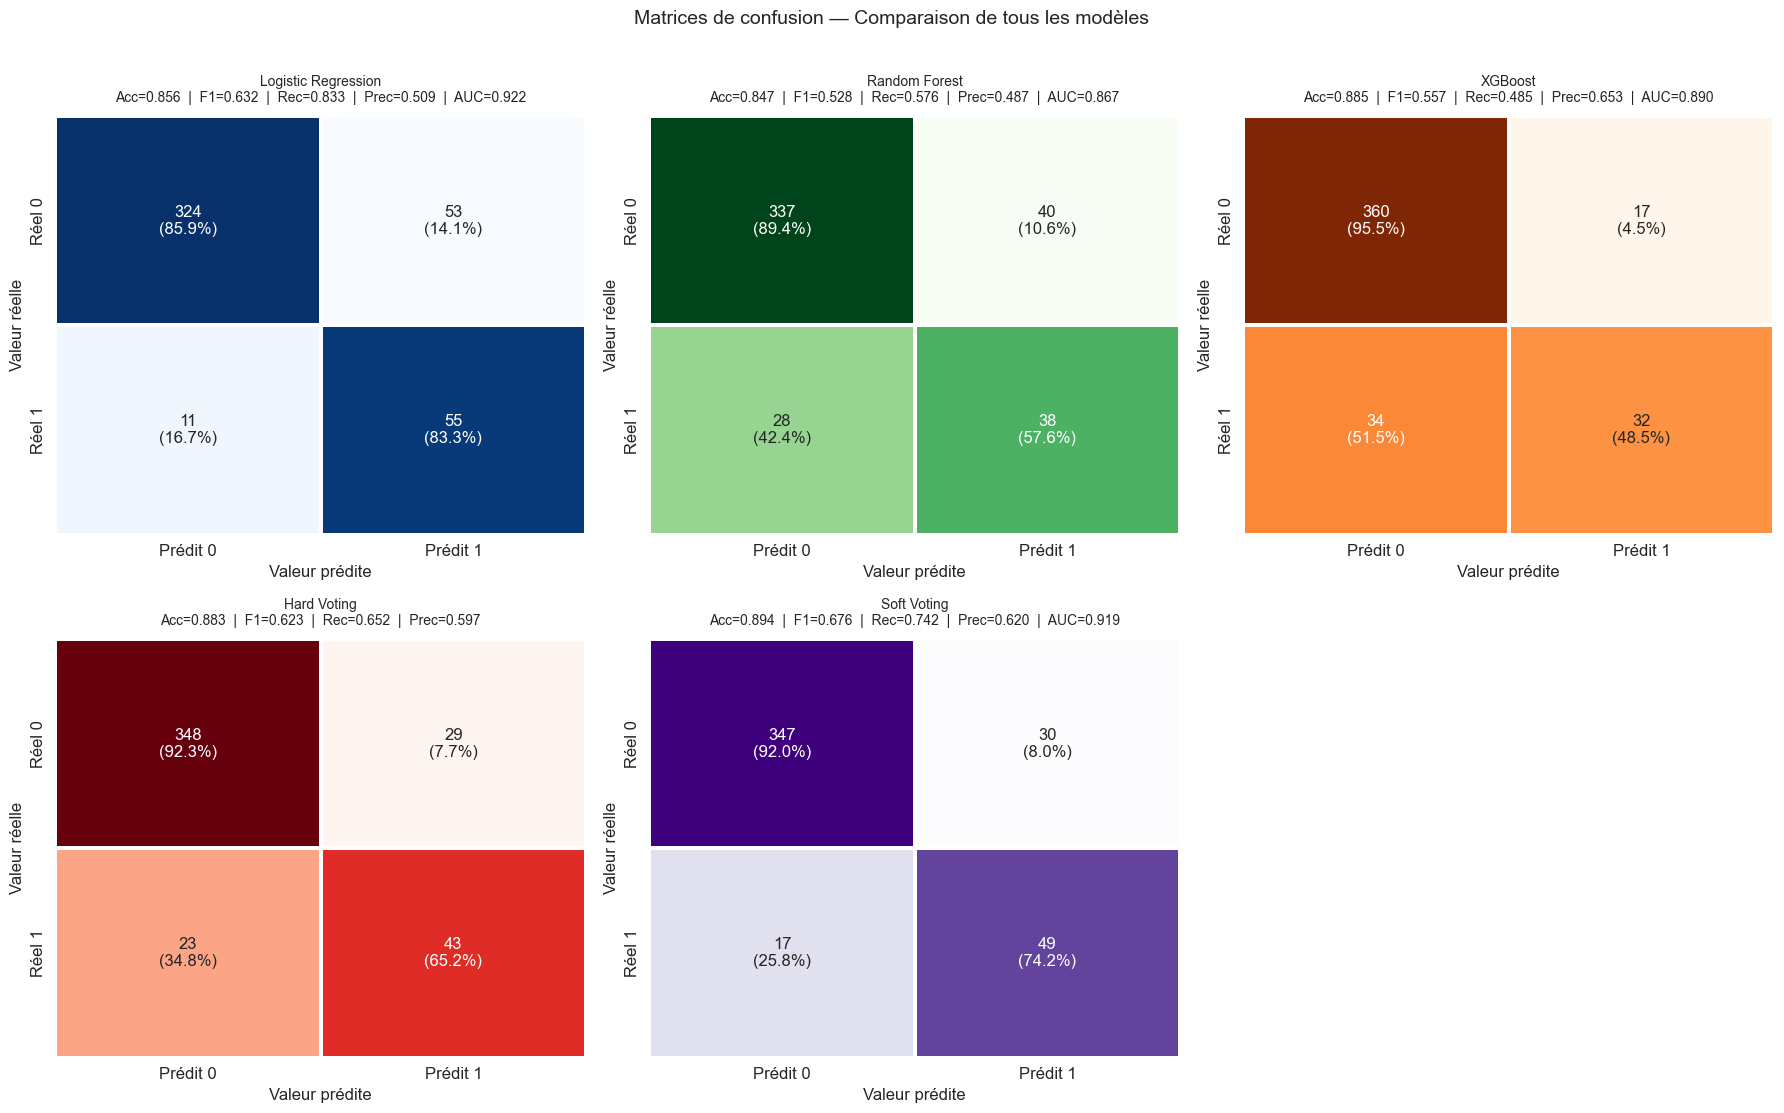

In [36]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

all_preds = {
    'Logistic Regression': (predictions['Logistic Regression']['y_pred'],
                            predictions['Logistic Regression']['y_proba']),
    'Random Forest'      : (predictions['Random Forest']['y_pred'],
                            predictions['Random Forest']['y_proba']),
    'XGBoost'            : (predictions['XGBoost']['y_pred'],
                            predictions['XGBoost']['y_proba']),
    'Hard Voting'        : (y_pred_hard, None),
    'Soft Voting'        : (y_pred_soft, y_proba_soft)
}

cmaps = ['Blues', 'Greens', 'Oranges', 'Reds', 'Purples']

for ax, (name, (y_pred_m, y_proba_m)), cmap in zip(axes, all_preds.items(), cmaps):
    cm     = confusion_matrix(y_test, y_pred_m)
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    annot = np.array([
        [f'{v}\n({p:.1f}%)' for v, p in zip(row_v, row_p)]
        for row_v, row_p in zip(cm, cm_pct)
    ])

    sns.heatmap(
        cm_pct, annot=annot, fmt='',
        cmap=cmap, ax=ax,
        xticklabels=['Prédit 0', 'Prédit 1'],
        yticklabels=['Réel 0',   'Réel 1'],
        linewidths=1.5, linecolor='white',
        cbar=False, annot_kws={'size': 12}
    )

    tn, fp, fn, tp = cm.ravel()
    acc  = accuracy_score(y_test, y_pred_m)
    f1   = f1_score(y_test, y_pred_m)
    rec  = recall_score(y_test, y_pred_m)
    prec = precision_score(y_test, y_pred_m)
    auc_str = (f'  |  AUC={roc_auc_score(y_test, y_proba_m):.3f}'
               if y_proba_m is not None else '')

    ax.set_title(
        f'{name}\n'
        f'Acc={acc:.3f}  |  F1={f1:.3f}  |  Rec={rec:.3f}  |  Prec={prec:.3f}{auc_str}',
        fontsize=10, pad=10
    )
    ax.set_ylabel('Valeur réelle')
    ax.set_xlabel('Valeur prédite')

# Masquer le 6e axe (grille 2x3 avec 5 modèles)
axes[5].set_visible(False)

plt.suptitle('Matrices de confusion — Comparaison de tous les modèles',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Les matrices de confusion montrent que les modèles distinguent globalement bien les clients répondants et non répondants. La régression logistique détecte le plus grand nombre de réponses positives (Recall élevé), mais génère davantage de faux positifs. XGBoost réduit fortement les faux positifs grâce à une meilleure précision, mais manque plus de clients intéressés. Le modèle **Soft Voting** offre le meilleur compromis global, avec une bonne détection des réponses positives et une excellente stabilité, ce qui en fait le modèle le plus adapté pour la prédiction des campagnes marketing.

## Sauvegardage du meillieur modèle (Soft Voting)

In [37]:
# Réentraînement sur la totalité du dataset

soft_voting_final = VotingClassifier(
    estimators=[
        ('lr',  best_lr),
        ('rf',  best_rf),
        ('xgb', best_xgb)
    ],
    voting='soft',
    n_jobs=-1
)

soft_voting_final.fit(X, y)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('lr', ...), ('rf', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",-1
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l1'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1


In [38]:
# Sauvegarde du modèle et des métadonnées

joblib.dump(soft_voting_final, 'models/soft_voting_final.pkl')
joblib.dump(X.columns.tolist(), 'models/feature_names.pkl')

['models/feature_names.pkl']